### Project Details

736 tech workers are losing their jobs every single day
in 2026.

Not from a recession.
Not from a financial crisis.
From artificial intelligence.

This dataset tracks every major tech layoff event of
2026 — verified from live sources updated as of
March 18, 2026 — giving you the most current
structured layoff data available anywhere on Kaggle

#### Column Descriptions

Column	Description  
company - Company name  
layoff_date - 	Date layoffs were announced or effective  
jobs_cut	 - Number of positions eliminated  
pct_workforce_cut - 	Percentage of total workforce eliminated  
sector - 	Industry sector of the company  
country	 - Country of company headquarters  
hq_city	 - Headquarters city  
ai_cited - 	True if AI was explicitly cited as reason  
reason_stated - 	Official reason given by company  
company_revenue_2025_bn	 - Company revenue in 2025 (USD billions)  
pre_layoff_headcount	 - Total employees before layoff  
stock_change_day_pct - 	Stock price % change on announcement day  
simultaneous_ai_investment_bn - 	Company AI capex spend in 2026 (USD bn)  
roles_most_affected - 	Job roles eliminated  
replacement_roles	 - New roles being hired  
ceo_quote	 - Direct CEO quote about the layoff  
layoffs_2024 - 	Number of layoffs at the same company in 2024  
layoffs_2025 - 	Number of layoffs at the same company in 2025  
verified_source - 	News source used to verify each event  
month - 	Month of layoff announcement  
quarter - 	Quarter of layoff announcement  
region - 	World region of headquarters  
layoff_size_category - 	Small / Medium / Large / Mega classification  
stock_reaction - 	Positive / Negative / Neutral on announcement  
laid_off_vs_headcount_pct - 	Verified % of workforce eliminated  
data_as_of - 	Date this dataset was last updated  


#### - Suggested Analysis Tasks
Classify whether a layoff will cause a stock priceincrease or decrease on announcement day  
Predict the percentage of workforce cut based on - sector, revenue and AI investment  
Cluster companies by their layoff behavior - and AI spending patterns  
Time series analysis of layoff frequency - across January to March 2026  
Compare AI-cited vs non-AI-cited layoffs by - size, sector and stock reaction  
Build a risk model — which sectors are most - vulnerable to AI-driven cuts next  
Visualize the paradox: jobs cut vs AI spend - for each company simultaneously  

#### - Questions to Explore
Do companies that cite AI as a reason see - a bigger stock price jump than those that don't?  
Which sector has the highest AI-cited layoff rate?  
Is there a correlation between company revenue - and the size of layoffs?  
Which country has been hit hardest by tech - layoffs in 2026?  
Do companies that cut the most replace workers - with the most AI investment?  
What percentage of laid-off roles have - AI replacement roles announced?  
Are layoffs getting larger or smaller as - 2026 progresses?  



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
import os
os.getcwd()

'c:\\Users\\OWNER\\Documents\\Data Analysis\\UDEMY\\Python\\12- EDA'

In [3]:
df = pd.read_csv("tech_layoffs_2026_tracker.csv")
df.head()

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
0,Amazon,2026-01-15,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,...,4000,14000,CNBC / NetworkWorld,January 2026,Q1 2026,North America,Mega (5K+),Positive,1.03,"March 18, 2026"
1,Block,2026-02-28,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,...,0,1000,CNBC / Crunchbase,February 2026,Q1 2026,North America,Large (2K-5K),Positive,40.00,"March 18, 2026"
2,Meta Reality Labs,2026-01-20,1500,10.0,Social Media/VR,USA,Menlo Park,True,Pivot from metaverse to AI research,164.5,...,0,500,InformationWeek / NYT,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.90,"March 18, 2026"
3,Atlassian,2026-03-14,1600,10.0,Enterprise Software,Australia,Sydney,True,Pivot to AI-first company strategy,5.1,...,0,500,TechRepublic / Metaintro,March 2026,Q1 2026,Asia-Pacific,Medium (500-2K),Positive,10.00,"March 18, 2026"
4,Oracle,2026-02-01,30000,15.0,Enterprise Software,USA,Austin,True,AI data centres replace human ops,52.9,...,6000,10000,IBTimes,February 2026,Q1 2026,North America,Mega (5K+),Positive,15.00,"March 18, 2026"


In [5]:
df.shape

(28, 26)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   company                        28 non-null     str    
 1   layoff_date                    28 non-null     str    
 2   jobs_cut                       28 non-null     int64  
 3   pct_workforce_cut              28 non-null     float64
 4   sector                         28 non-null     str    
 5   country                        28 non-null     str    
 6   hq_city                        28 non-null     str    
 7   ai_cited                       28 non-null     bool   
 8   reason_stated                  28 non-null     str    
 9   company_revenue_2025_bn        28 non-null     float64
 10  pre_layoff_headcount           28 non-null     int64  
 11  stock_change_day_pct           28 non-null     float64
 12  simultaneous_ai_investment_bn  28 non-null     float64
 13  rol

In [7]:
df.describe()

,jobs_cut,pct_workforce_cut,company_revenue_2025_bn,pre_layoff_headcount,stock_change_day_pct,simultaneous_ai_investment_bn,layoffs_2024,layoffs_2025,laid_off_vs_headcount_pct
count,28.000000,28.000000,28.00000,2.800000e+01,28.000000,28.000000,28.000000,28.000000,28.000000
mean,3612.357143,10.639286,63.62500,1.076631e+05,0.832143,14.046429,944.642857,1951.785714,10.452143
std,6546.591373,10.433505,139.44986,2.915339e+05,1.742721,34.751824,1615.511574,3328.482085,10.719330
min,50.000000,0.100000,0.00000,2.500000e+03,-2.100000,0.000000,0.000000,0.000000,0.320000
25%,989.500000,2.525000,3.50000,8.750000e+03,-0.325000,0.000000,0.000000,0.000000,1.975000
50%,1000.000000,7.750000,9.40000,1.850000e+04,0.650000,0.450000,0.000000,500.000000,7.205000
75%,2050.000000,15.000000,53.90000,8.050000e+04,1.850000,2.250000,1125.000000,1812.500000,15.810000
max,30000.000000,40.000000,716.90000,1.550000e+06,5.800000,115.000000,6000.000000,14000.000000,40.000000


In [8]:
df.isnull().sum()

company                          0
layoff_date                      0
jobs_cut                         0
pct_workforce_cut                0
sector                           0
country                          0
hq_city                          0
ai_cited                         0
reason_stated                    0
company_revenue_2025_bn          0
pre_layoff_headcount             0
stock_change_day_pct             0
simultaneous_ai_investment_bn    0
roles_most_affected              0
replacement_roles                0
ceo_quote                        0
layoffs_2024                     0
layoffs_2025                     0
verified_source                  0
month                            0
quarter                          0
region                           0
layoff_size_category             0
stock_reaction                   0
laid_off_vs_headcount_pct        0
data_as_of                       0
dtype: int64

In [10]:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
dtype: bool

### observation
No Missing Value

In [23]:
### Data Cleaning

df_copy= df.copy()

In [25]:
df_copy['layoff_date']  = pd.to_datetime(df_copy['layoff_date'])
df_copy['month']  = pd.to_datetime(df_copy['month'])
df_copy['data_as_of']  = pd.to_datetime(df_copy['data_as_of'])

In [26]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   company                        28 non-null     str           
 1   layoff_date                    28 non-null     datetime64[us]
 2   jobs_cut                       28 non-null     int64         
 3   pct_workforce_cut              28 non-null     float64       
 4   sector                         28 non-null     str           
 5   country                        28 non-null     str           
 6   hq_city                        28 non-null     str           
 7   ai_cited                       28 non-null     bool          
 8   reason_stated                  28 non-null     str           
 9   company_revenue_2025_bn        28 non-null     float64       
 10  pre_layoff_headcount           28 non-null     int64         
 11  stock_change_day_pct           2

### EDA

In [73]:
df_copy=df_copy.drop(['data_as_of','data_as_of'],axis=1)

In [31]:
df.columns

Index(['company', 'layoff_date', 'jobs_cut', 'pct_workforce_cut', 'sector',
       'country', 'hq_city', 'ai_cited', 'reason_stated',
       'company_revenue_2025_bn', 'pre_layoff_headcount',
       'stock_change_day_pct', 'simultaneous_ai_investment_bn',
       'roles_most_affected', 'replacement_roles', 'ceo_quote', 'layoffs_2024',
       'layoffs_2025', 'verified_source', 'month', 'quarter', 'region',
       'layoff_size_category', 'stock_reaction', 'laid_off_vs_headcount_pct',
       'data_as_of'],
      dtype='str')

In [76]:
categorical_col= [column for column in df_copy.columns if df_copy[column].dtype == 'str']
numeric_col= [column for column in df_copy.columns if df_copy[column].dtype != 'str']


In [45]:
###Unique values of each column

for col in df_copy[categorical_col].columns:
    print(col)
    print(df_copy[col].unique())
    print('---------------')

company
<StringArray>
[                  'Amazon',                    'Block',
        'Meta Reality Labs',                'Atlassian',
                   'Oracle',               'Salesforce',
                 'Autodesk',                     'eBay',
                'Pinterest',                 'Ericsson',
                     'ASML',                'ams OSRAM',
                    'Ocado',          'WiseTech Global',
                    'Cisco',                 'T-Mobile',
       'SK Battery America',                'Walgreens',
               'Telefonica',                      'xAI',
       'Palo Alto Networks',                 'Livspace',
      'General Motors Tech',                  'Workday',
           'Ergo Insurance',             'Algoma Steel',
 'Meta Platforms (Planned)']
Length: 27, dtype: str
---------------
sector
<StringArray>
[        'E-Commerce/Cloud',                  'Fintech',
          'Social Media/VR',      'Enterprise Software',
                 'CRM/SaaS',      

### Explore Data for Insights


#### Classify whether a layoff will cause a stock priceincrease or decrease on announcement day  

<Axes: xlabel='company', ylabel='jobs_cut'>

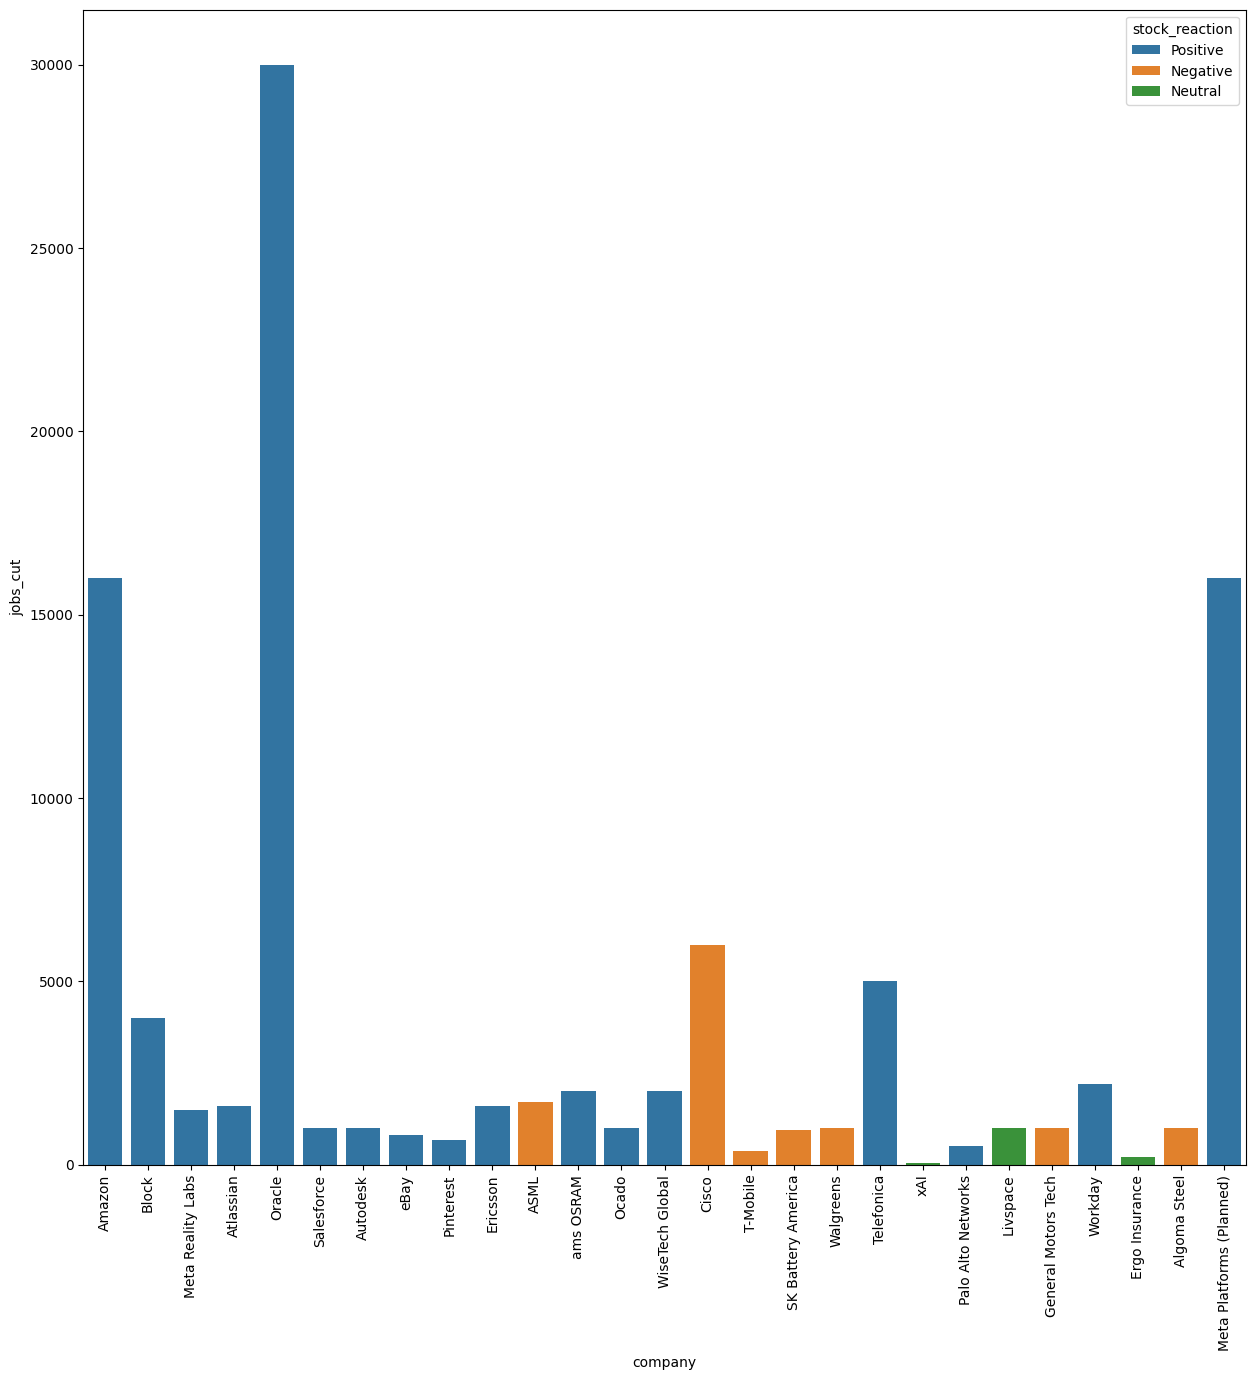

In [53]:
plt.figure(figsize=(15, 15))
plt.xticks(rotation=90)
sns.barplot(data=df_copy, x='company', y='jobs_cut',hue='stock_reaction')

#### Predict the percentage of workforce cut based on - sector, revenue and AI investment

In [ ]:
df_copy.groupby(['sector','company_revenue_2025_bn','simultaneous_ai_investment_bn'])['pct_workforce_cut'].mean()

sector                    company_revenue_2025_bn  simultaneous_ai_investment_bn
AI Research               0.0                      6.0                               2.0
Automotive Tech           180.0                    3.0                               2.0
CRM/SaaS                  37.9                     5.0                               1.4
Cybersecurity             8.0                      0.5                               2.0
Design Software           5.9                      0.3                               9.0
E-Commerce                10.3                     0.8                               5.0
E-Commerce/Cloud          716.9                    100.0                             2.7
EV Batteries              8.4                      0.0                              37.3
Enterprise SaaS           8.5                      1.5                               8.5
Enterprise Software       5.1                      0.5                              10.0
                          52.

<Axes: title={'center': 'Jobs cut by sector '}, xlabel='sector', ylabel='jobs_cut'>

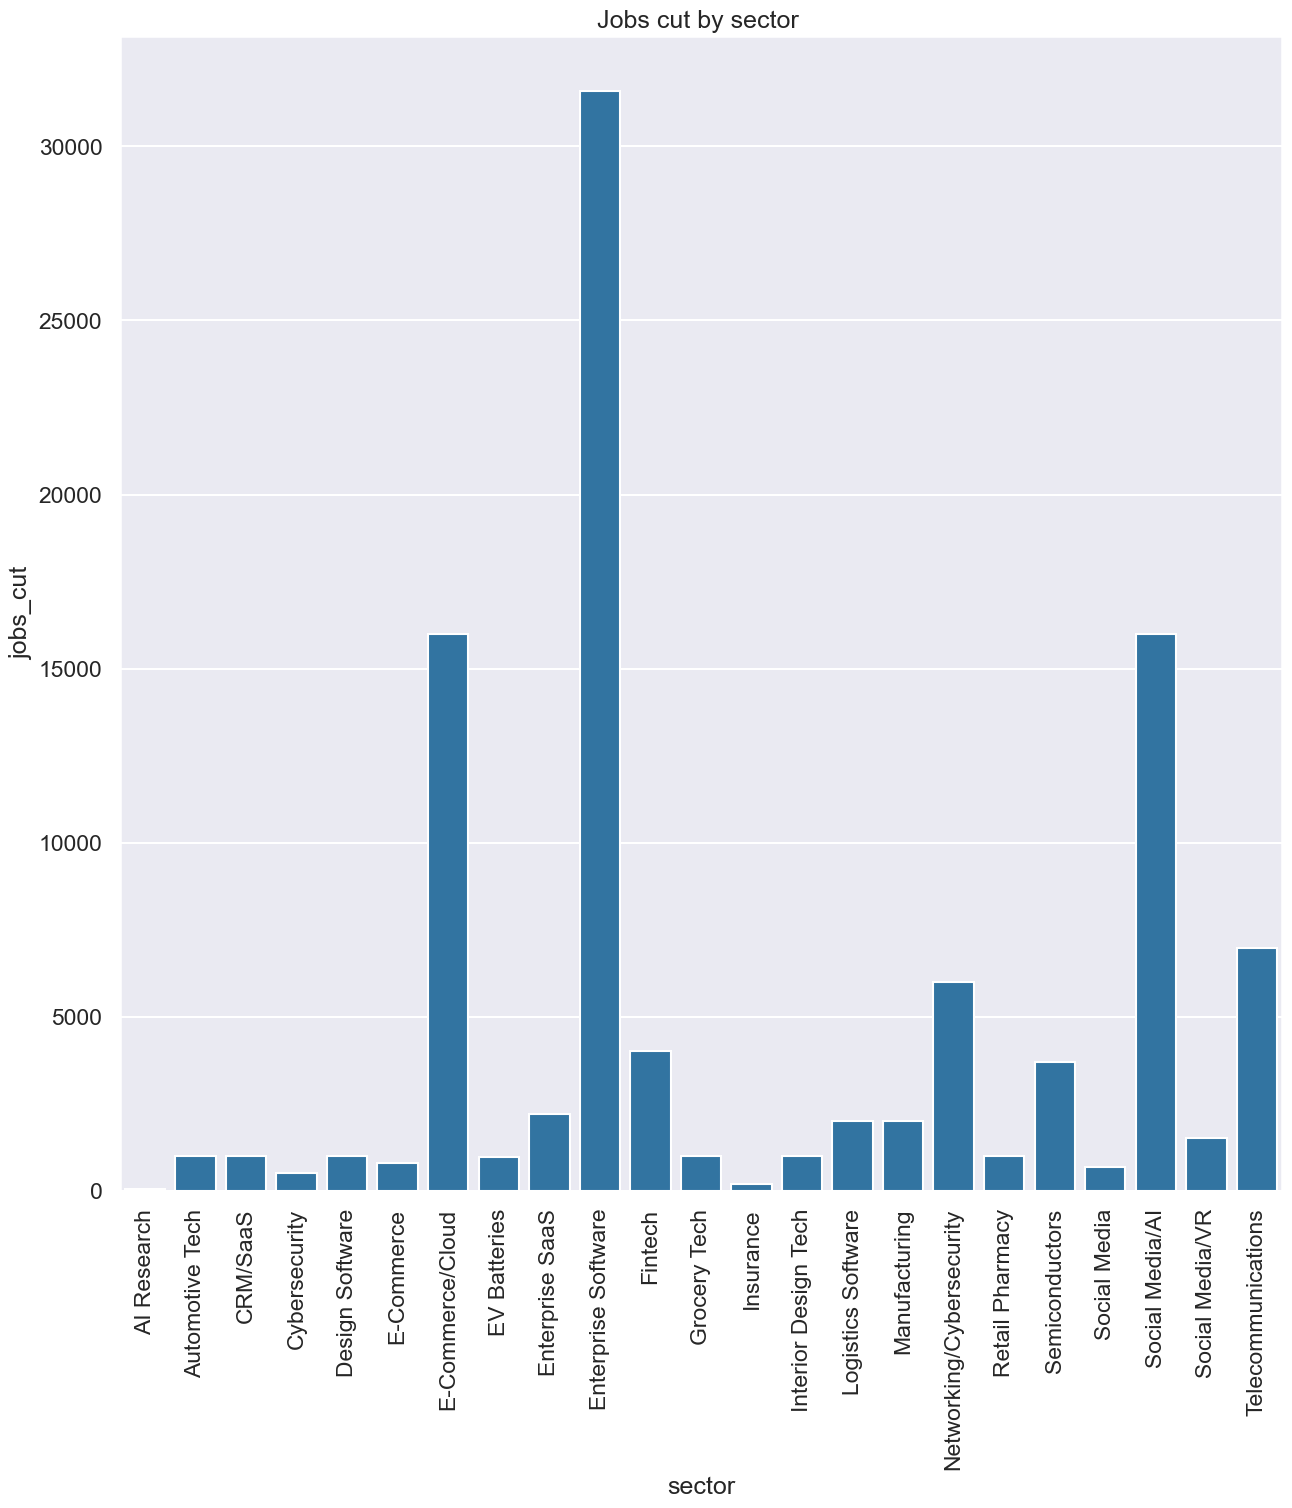

In [68]:
df_sector=df_copy.groupby(['sector'])['jobs_cut'].sum().reset_index()
plt.figure(figsize = (15,15))
plt.xticks(rotation=90)
plt.title('Jobs cut by sector ')
sns.barplot(x='sector',y='jobs_cut',data=df_sector)

###Observation

Enterprise software, e-commerce, social media and ai are sectors with most cut off

#### correlation between numeric columns

<Axes: >

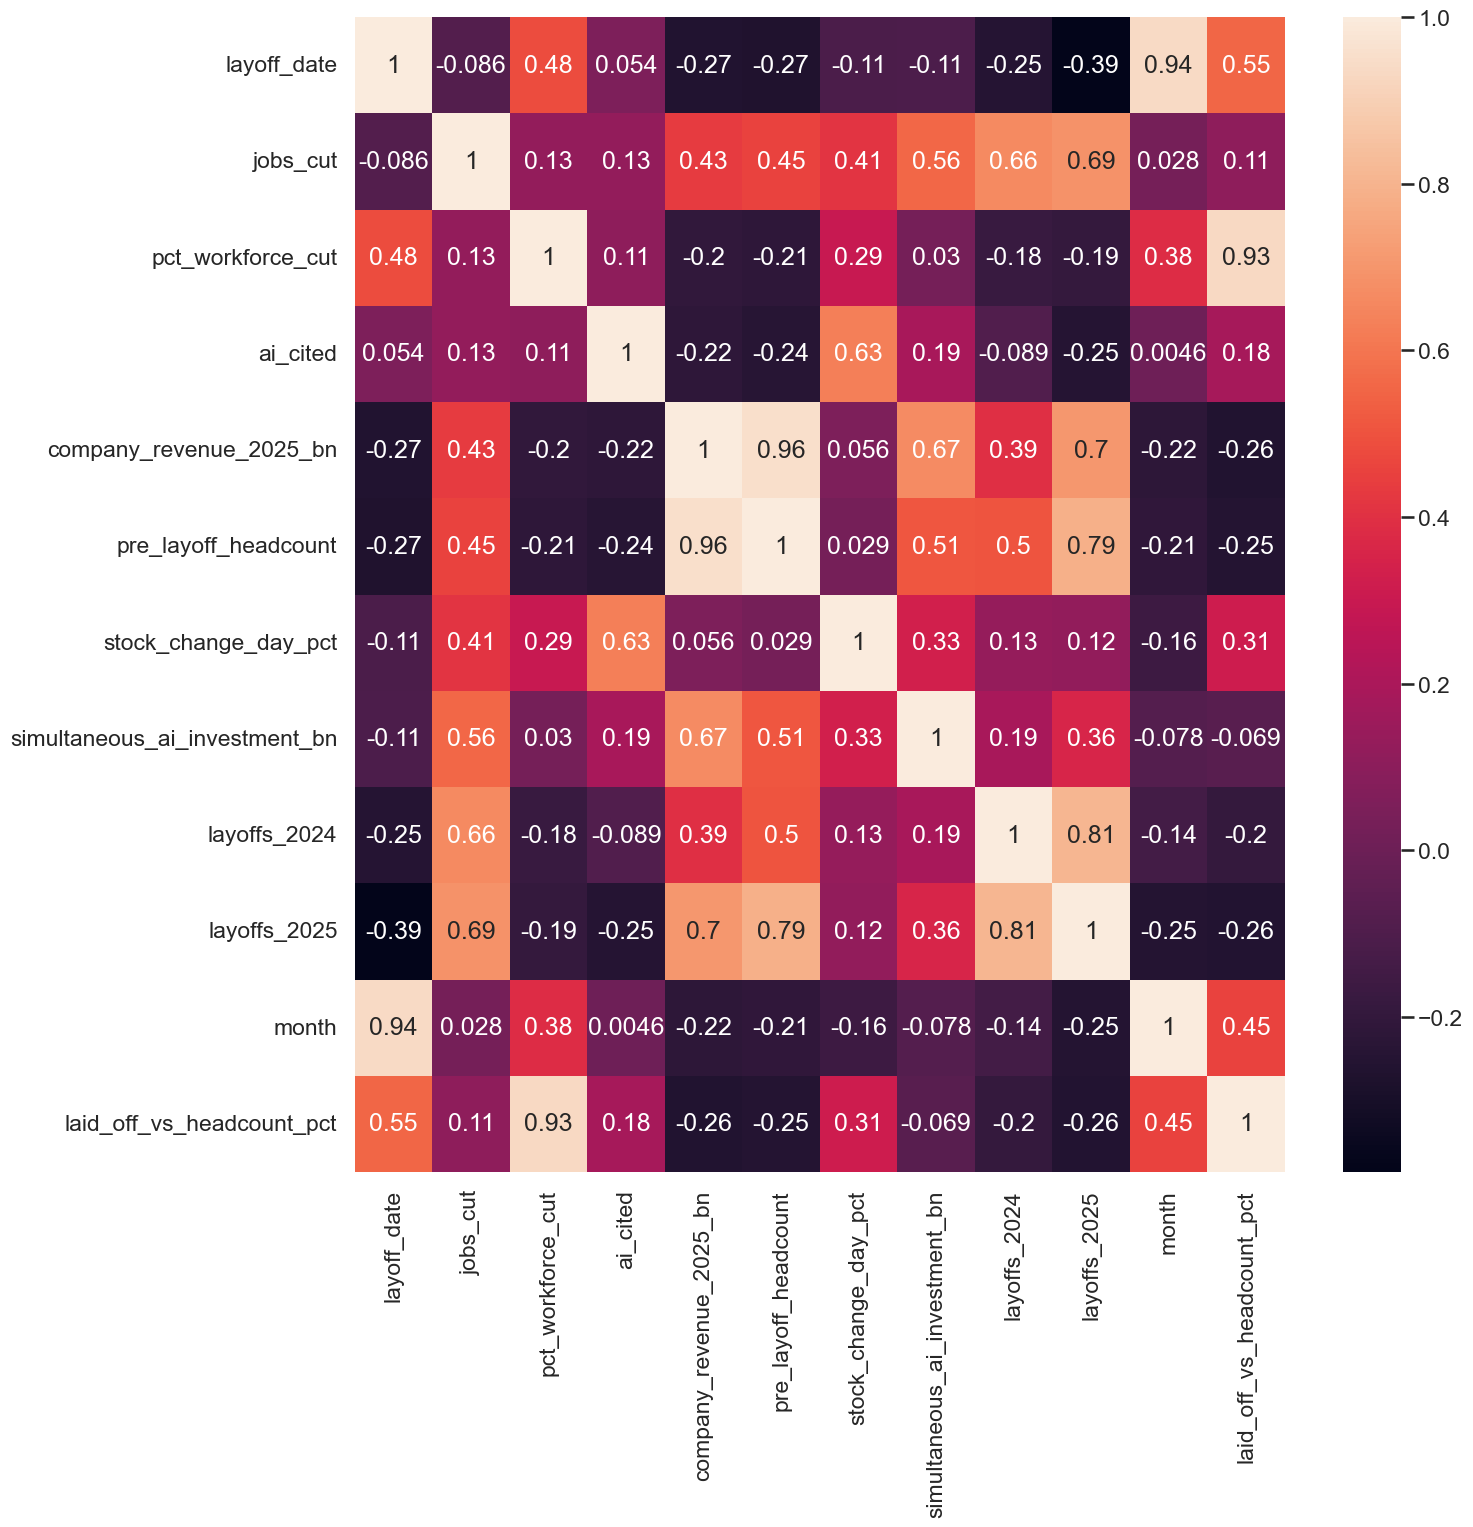

In [78]:
plt.figure(figsize=(15,15))
sns.heatmap(df_copy[numeric_col].corr(),annot=True)

### Proportion of count data on numerical columns

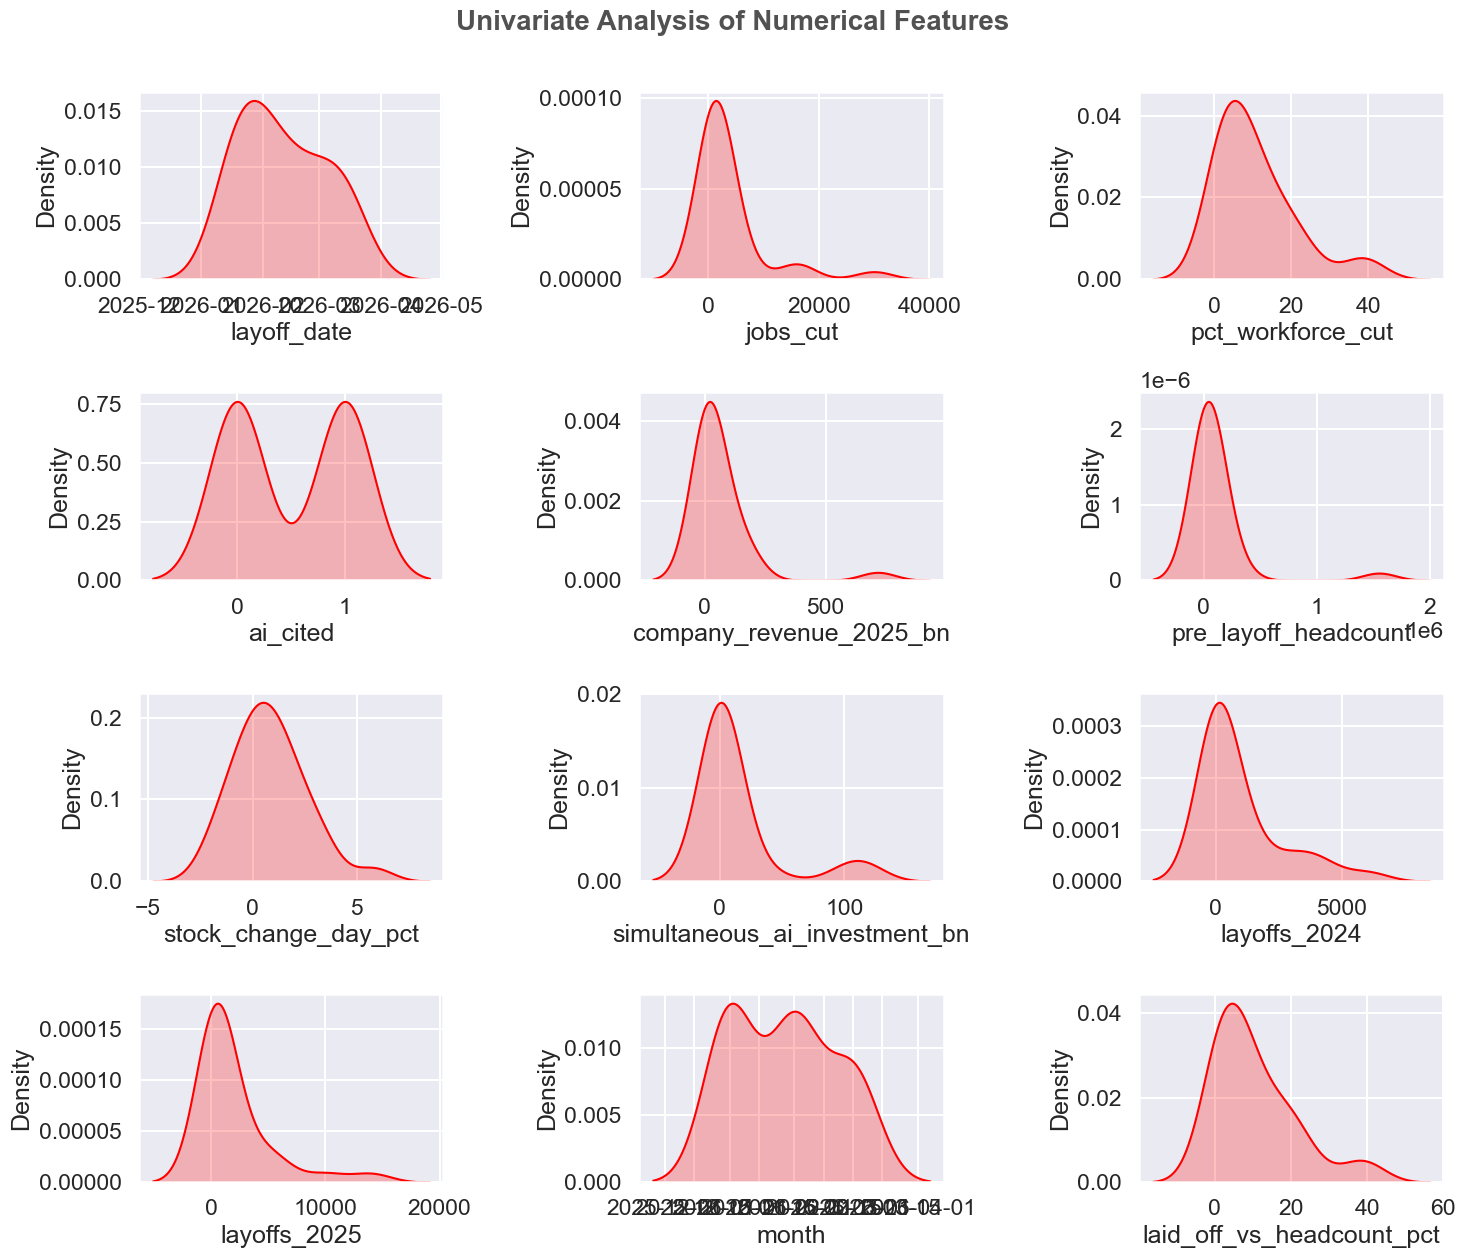

In [ ]:

plt.figure(figsize=(15, 15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_col)):
    plt.subplot(5, 3, i+1)
    sns.kdeplot(x=df_copy[numeric_col[i]],shade=True, color='r')
    plt.xlabel(numeric_col[i])
    plt.tight_layout()

#### Time series analysis of layoff frequency - across January to March 2026  

<Axes: xlabel='layoff_date', ylabel='laid_off_vs_headcount_pct'>

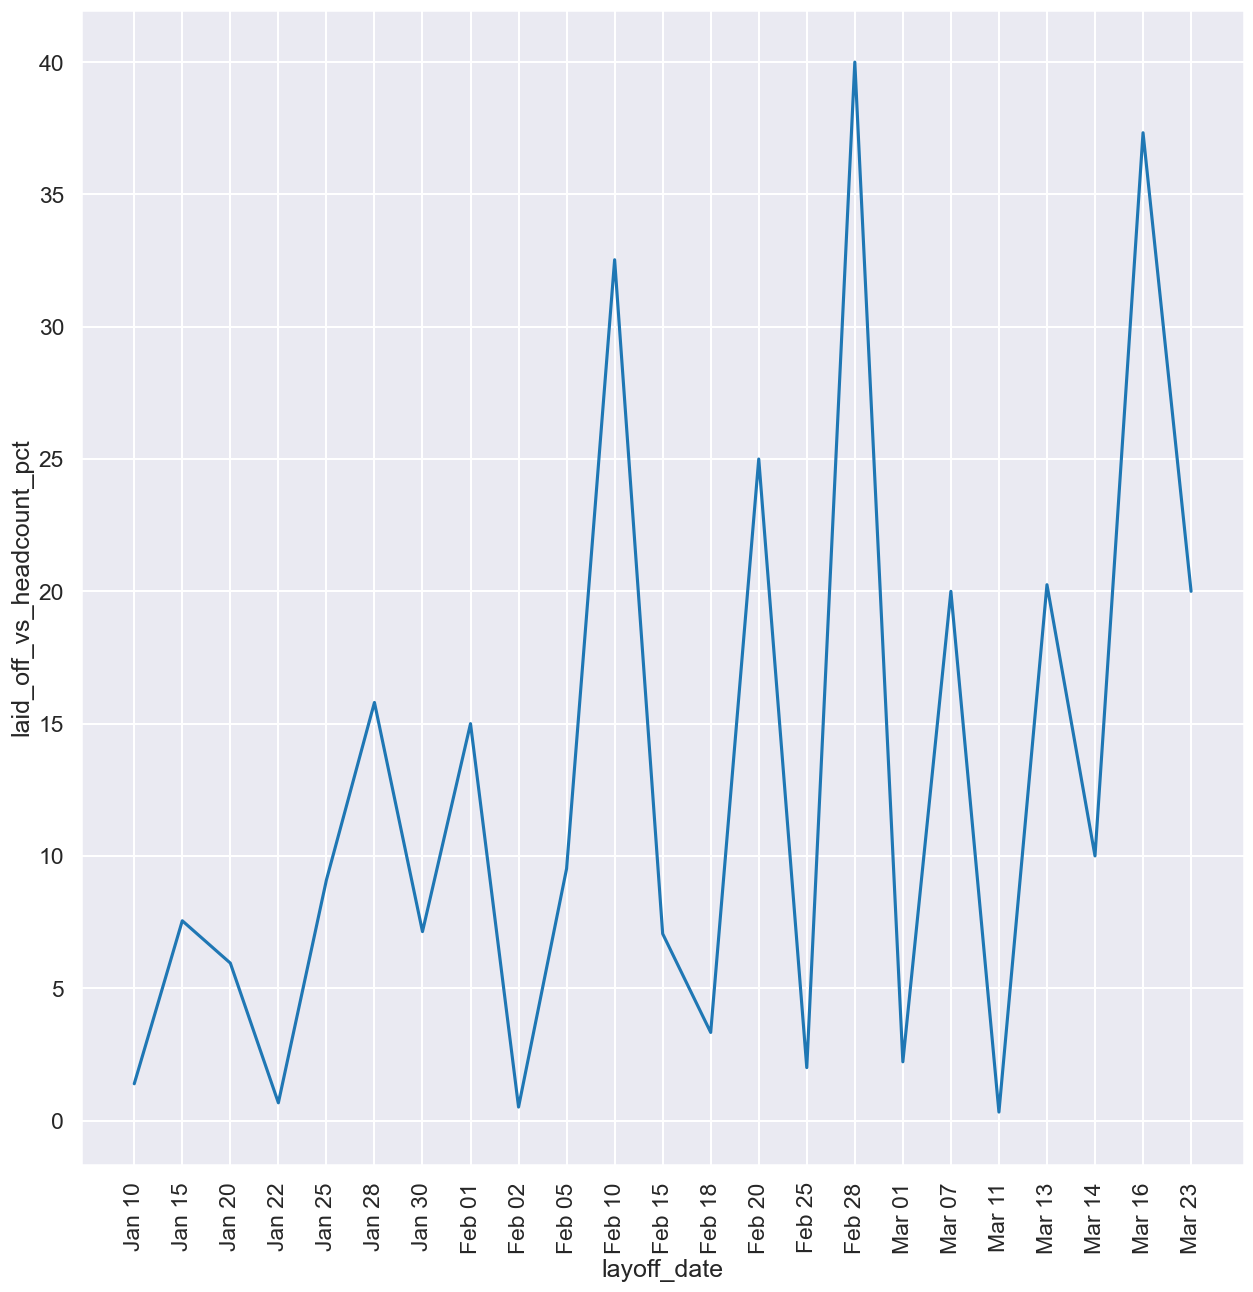

In [109]:
layoff_freq = df_copy.groupby('layoff_date')['laid_off_vs_headcount_pct'].sum().reset_index()
month_day=layoff_freq['layoff_date'].dt.strftime('%b %d')
plt.figure(figsize=(15,15))
plt.xticks(rotation=90)
sns.lineplot(x=month_day, y='laid_off_vs_headcount_pct',data=layoff_freq)

#### Compare AI-cited vs non-AI-cited layoffs by - size, sector and stock reaction 

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'Fintech'),
  Text(1, 0, 'Social Media/VR'),
  Text(2, 0, 'Enterprise Software'),
  Text(3, 0, 'CRM/SaaS'),
  Text(4, 0, 'E-Commerce'),
  Text(5, 0, 'Social Media'),
  Text(6, 0, 'Grocery Tech'),
  Text(7, 0, 'Logistics Software'),
  Text(8, 0, 'AI Research'),
  Text(9, 0, 'Interior Design Tech'),
  Text(10, 0, 'Enterprise SaaS'),
  Text(11, 0, 'Insurance'),
  Text(12, 0, 'Social Media/AI')])

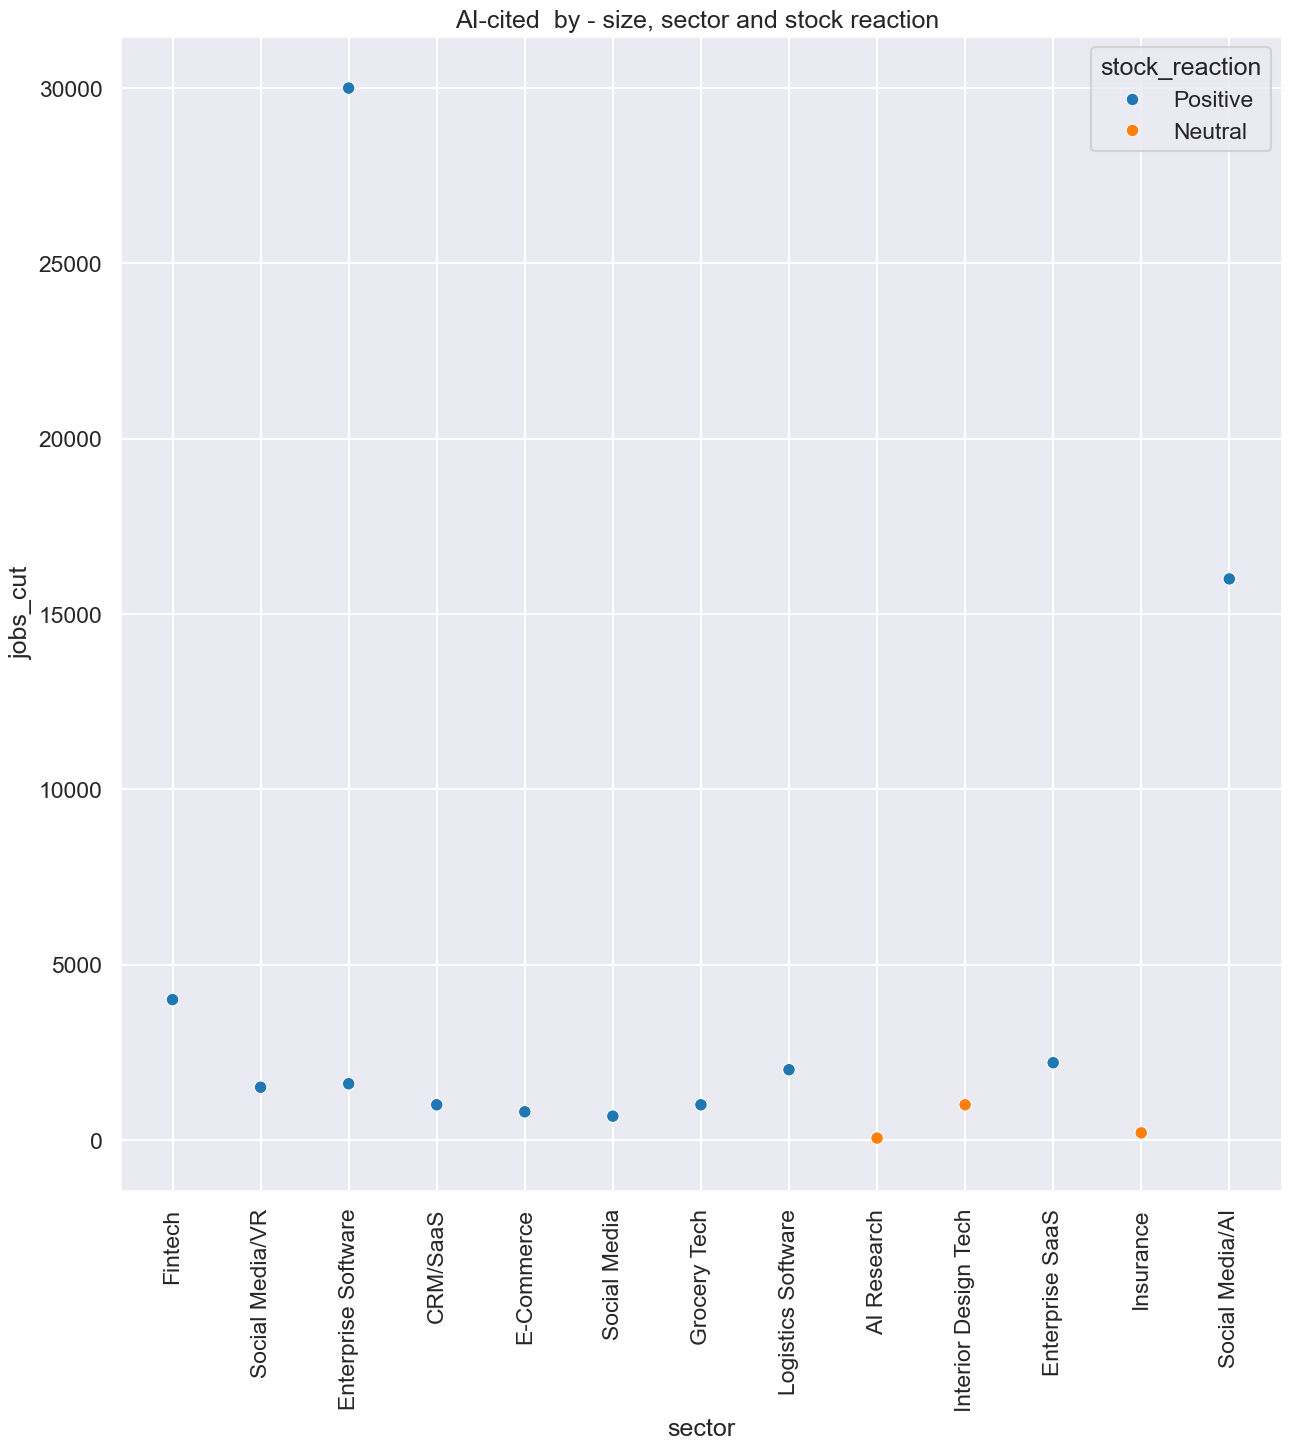

In [120]:
df_ai_cited=df_copy[df_copy['ai_cited']==True]
df_non_ai_cited=df_copy[df_copy['ai_cited']==False]

plt.figure(figsize=(15,15))
plt.title('AI-cited  by - size, sector and stock reaction ')
sns.scatterplot(x='sector',y='jobs_cut',data=df_ai_cited,hue='stock_reaction')
plt.xticks(rotation=90)



([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'E-Commerce/Cloud'),
  Text(1, 0, 'Design Software'),
  Text(2, 0, 'Telecommunications'),
  Text(3, 0, 'Semiconductors'),
  Text(4, 0, 'Networking/Cybersecurity'),
  Text(5, 0, 'EV Batteries'),
  Text(6, 0, 'Retail Pharmacy'),
  Text(7, 0, 'Cybersecurity'),
  Text(8, 0, 'Automotive Tech'),
  Text(9, 0, 'Manufacturing')])

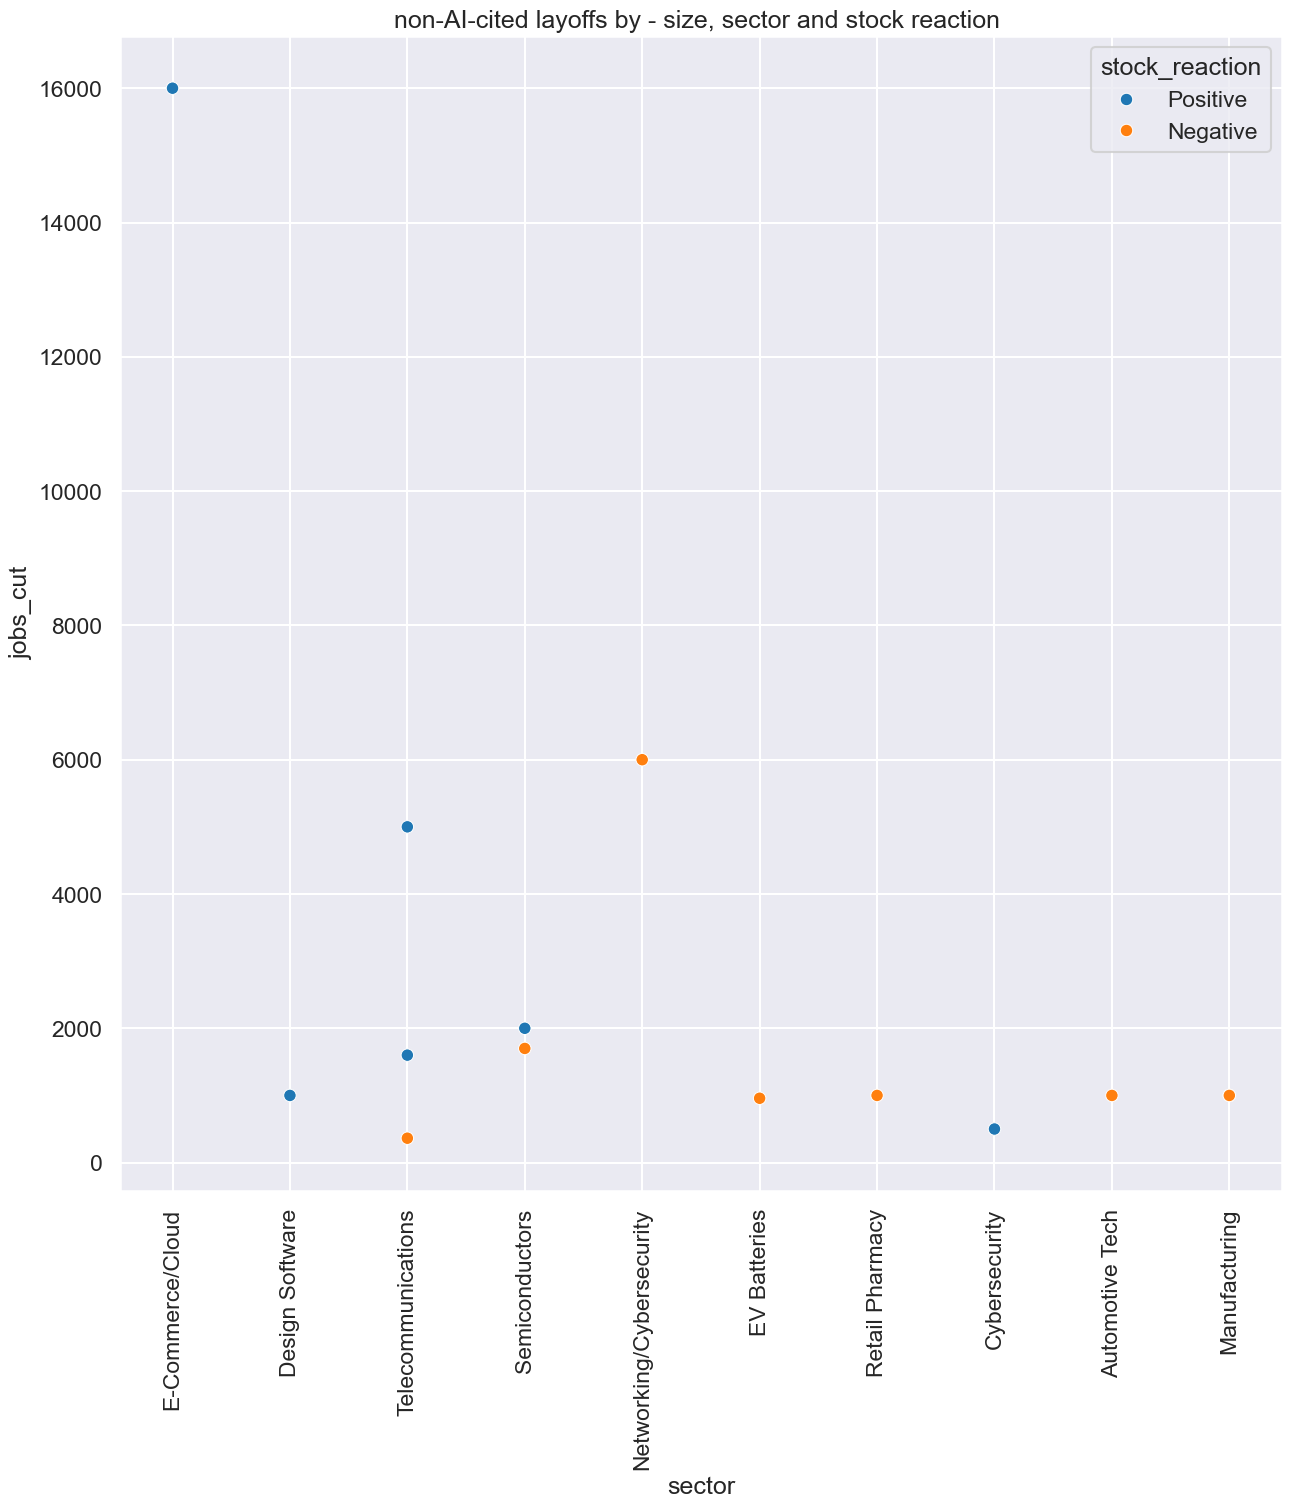

In [ ]:
plt.figure(figsize=(15,15))
plt.title('non-AI-cited layoffs by - size, sector and stock reaction ')
sns.scatter(x='sector',y='jobs_cut',data=df_non_ai_cited,hue='stock_reaction')
plt.xticks(rotation=90)

#### Visualize the paradox: jobs cut vs AI spend - for each company simultaneously 

In [123]:
df_copy.columns

Index(['company', 'layoff_date', 'jobs_cut', 'pct_workforce_cut', 'sector',
       'country', 'hq_city', 'ai_cited', 'reason_stated',
       'company_revenue_2025_bn', 'pre_layoff_headcount',
       'stock_change_day_pct', 'simultaneous_ai_investment_bn',
       'roles_most_affected', 'replacement_roles', 'ceo_quote', 'layoffs_2024',
       'layoffs_2025', 'verified_source', 'month', 'quarter', 'region',
       'layoff_size_category', 'stock_reaction', 'laid_off_vs_headcount_pct'],
      dtype='str')

Text(0.5, 1.0, 'jobs cut vs AI spend - for each company simultaneously ')

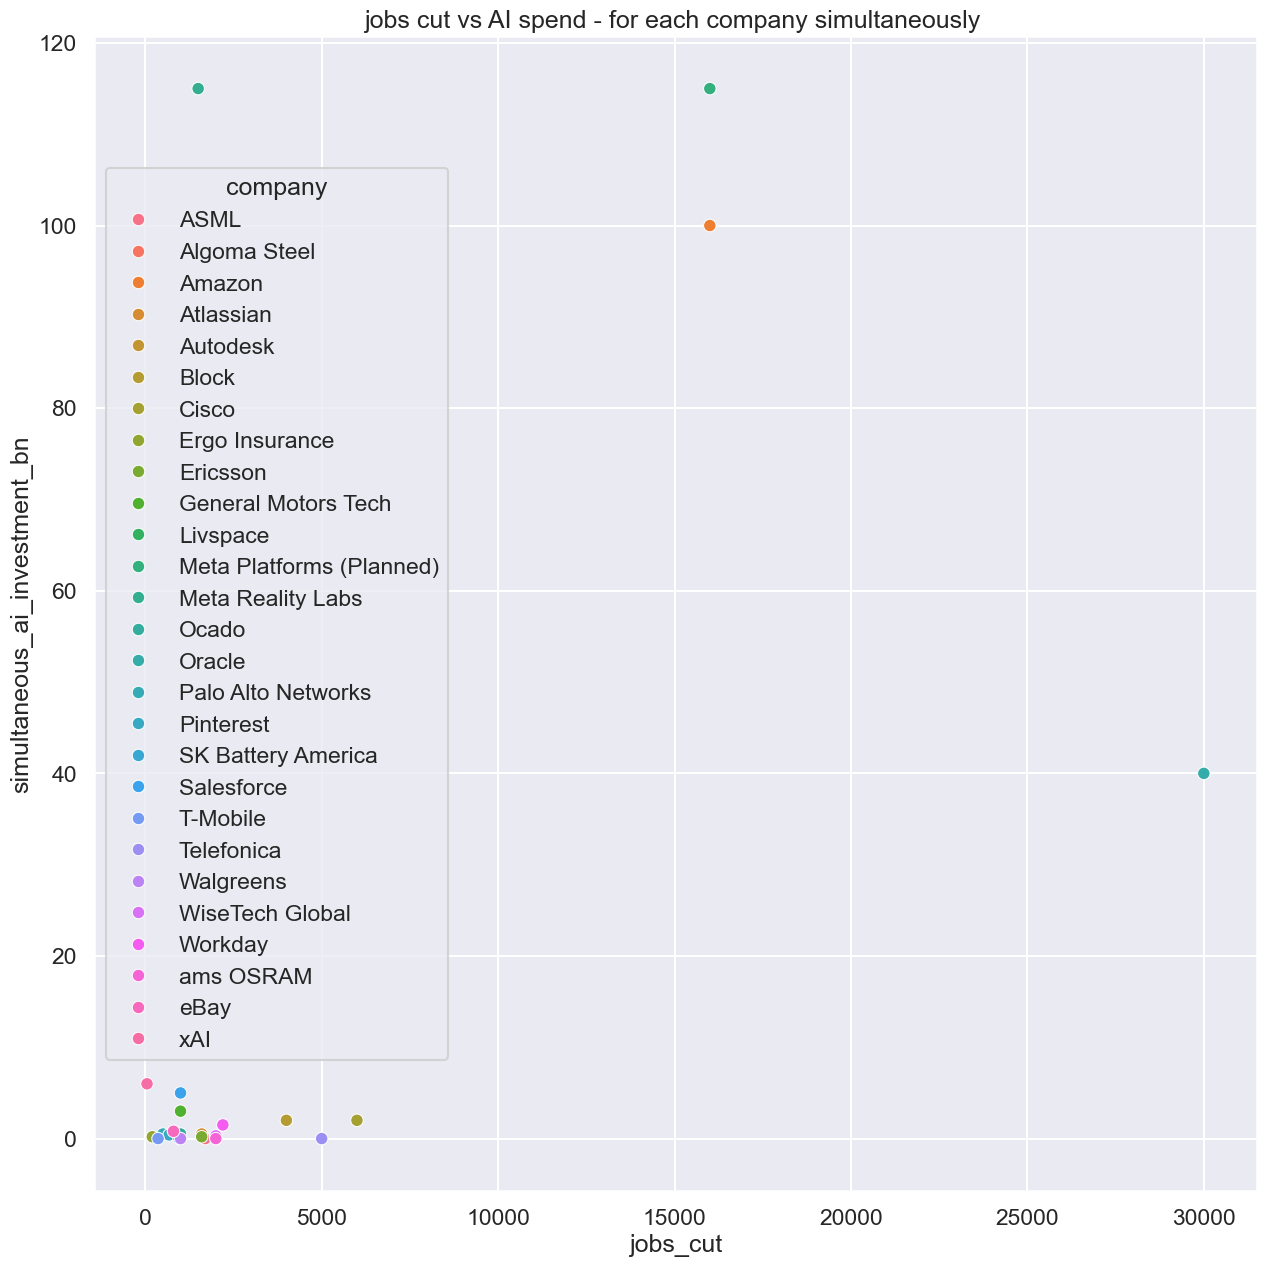

In [138]:
company_df=df_copy.groupby('company')[['jobs_cut','simultaneous_ai_investment_bn']].sum().reset_index()

plt.figure(figsize=(15,15))
sns.scatterplot(x='jobs_cut',y='simultaneous_ai_investment_bn',hue='company',data=company_df)
plt.title('jobs cut vs AI spend - for each company simultaneously ')

#### Do companies that cite AI as a reason see - a bigger stock price jump than those that don't? 

<Axes: title={'center': 'AI-cited vs non_ai_cited  by  company and stock reaction '}, xlabel='company', ylabel='stock_reaction'>

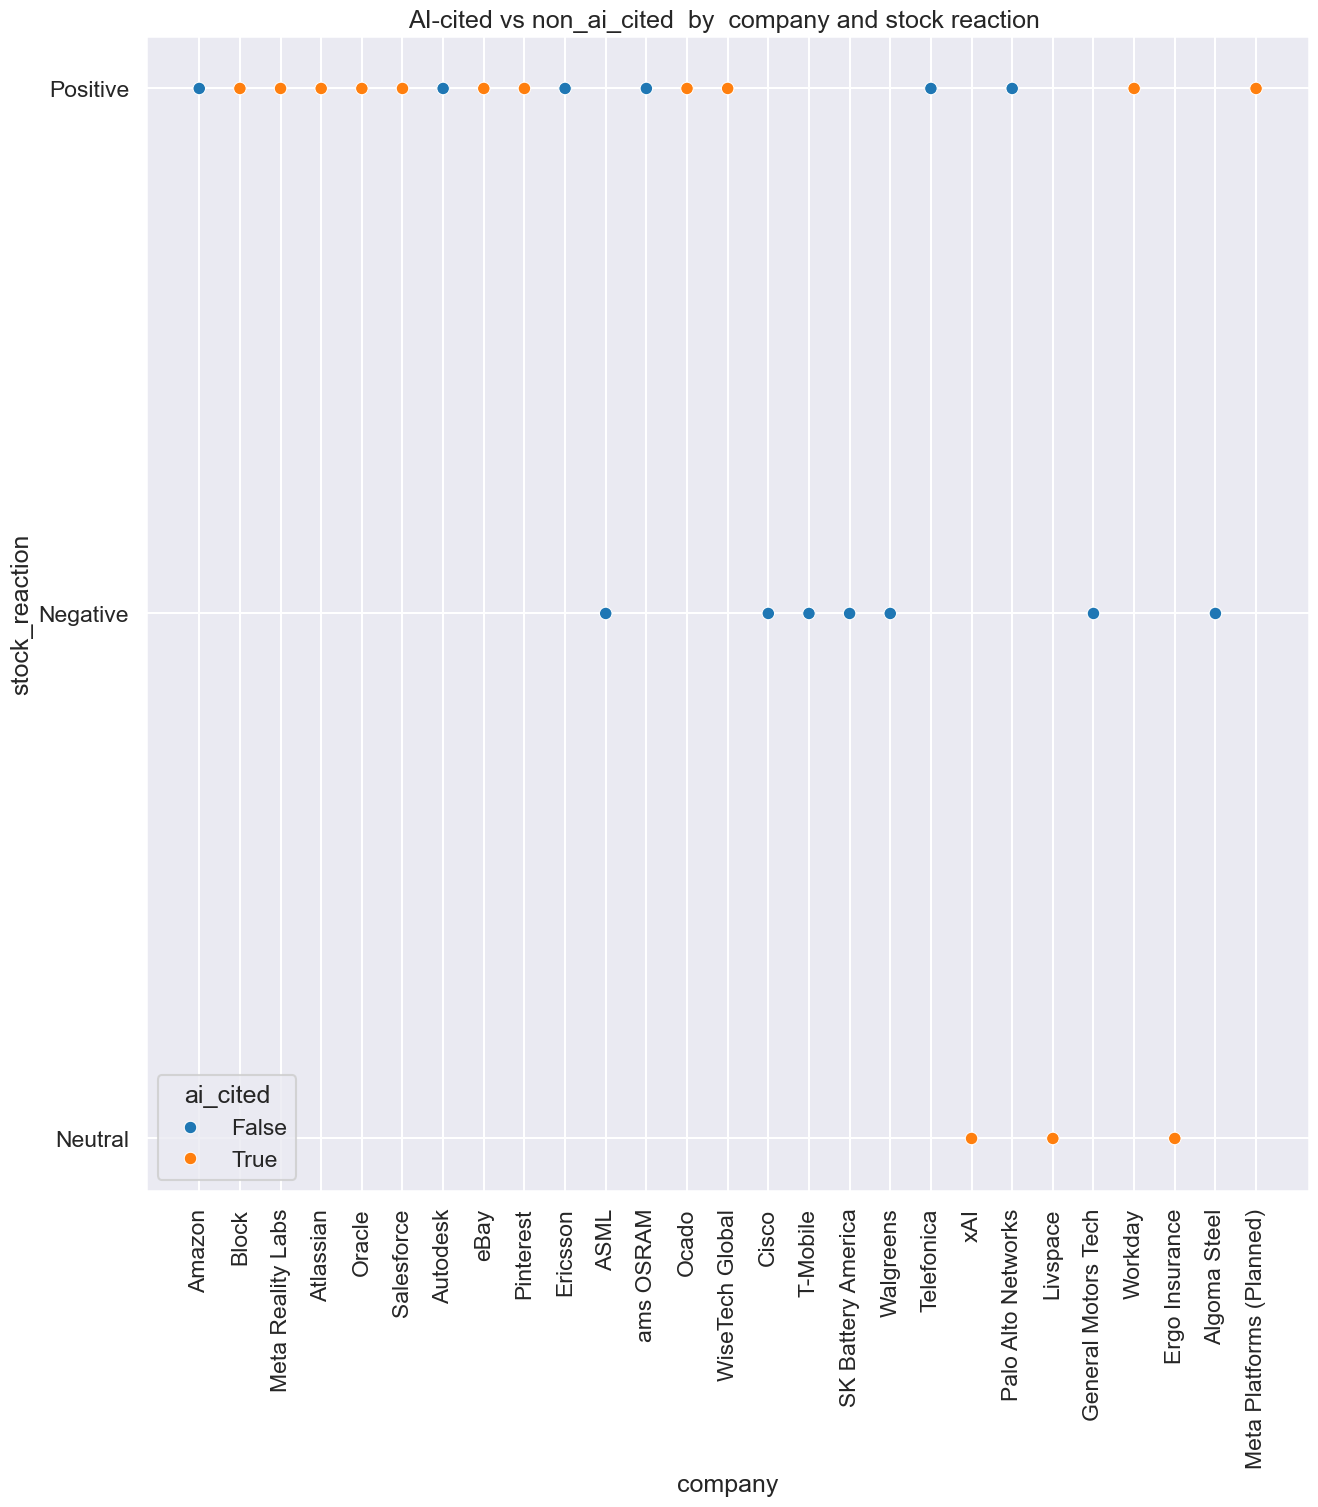

In [142]:


plt.figure(figsize=(15,15))
plt.title('AI-cited vs non_ai_cited  by  company and stock reaction ')
plt.xticks(rotation=90)
sns.scatterplot(x='company',y='stock_reaction',data=df_copy,hue='ai_cited')


In [143]:
# ANSWER: YES THEY DO

#### Which sector has the highest AI-cited layoff rate? 

<BarContainer object of 14 artists>

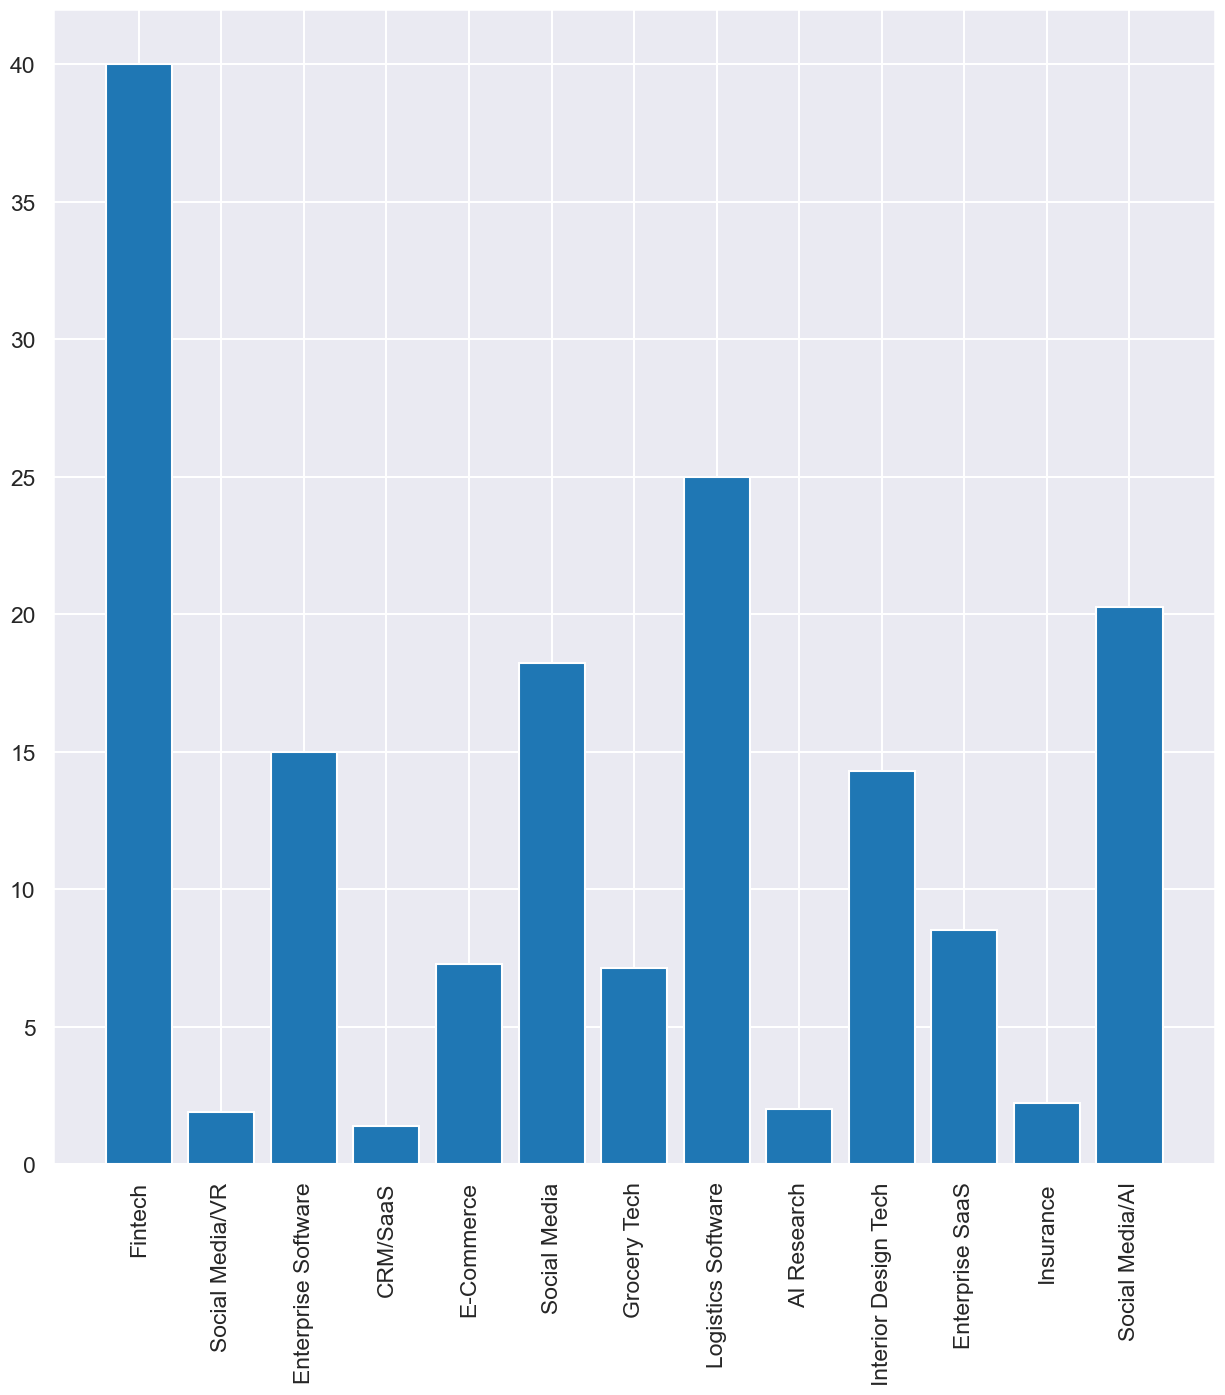

In [147]:
df_ai_cited= df[df['ai_cited']==True]

plt.figure(figsize=(15,15))
plt.xticks(rotation=90)
plt.bar(df_ai_cited['sector'], df_ai_cited['laid_off_vs_headcount_pct'])

In [148]:
# ANSWER: FINTECH

#### Is there a correlation between company revenue - and the size of layoffs?

In [151]:
df_copy['company_revenue_2025_bn'].corr(df['jobs_cut'])

np.float64(0.434518552886095)

In [ ]:
# ANSWER: A positive correlation of 43%

#### Which country has been hit hardest by tech - layoffs in 2026?  

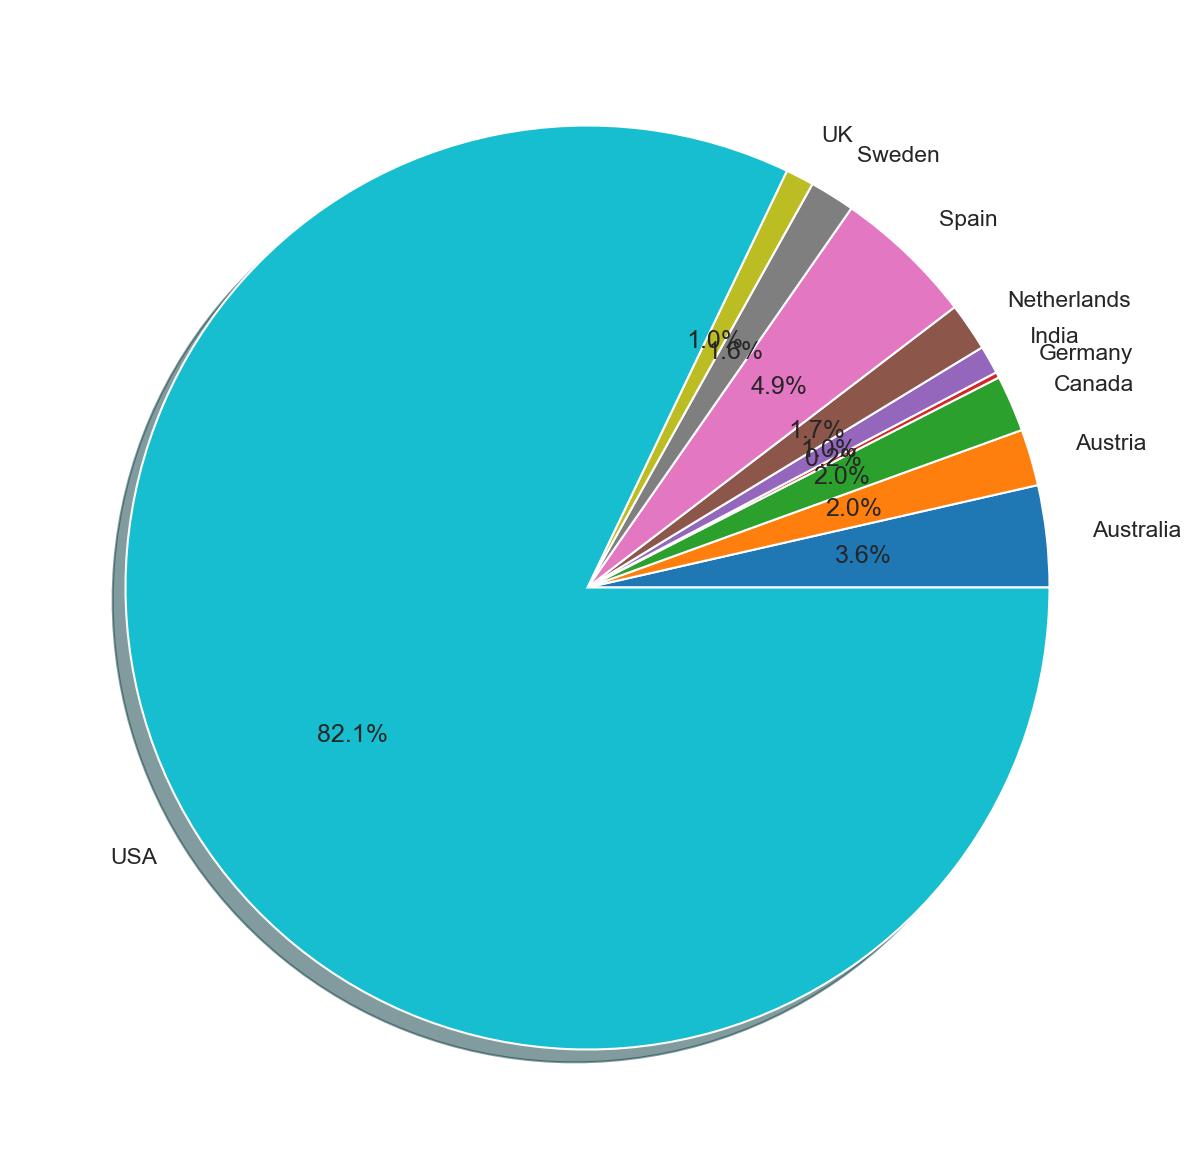

In [210]:
country_df=df_copy.groupby('country')['jobs_cut'].sum().reset_index()
plt.figure(figsize=(15,15))
plt.pie('jobs_cut',labels='country', autopct="%1.1f%%", shadow = True, data=country_df)
plt.show()

In [ ]:
# ANSWER: USA

#### Do companies that cut the most replace workers with the most AI investment?  

<Figure size 1500x1500 with 0 Axes>

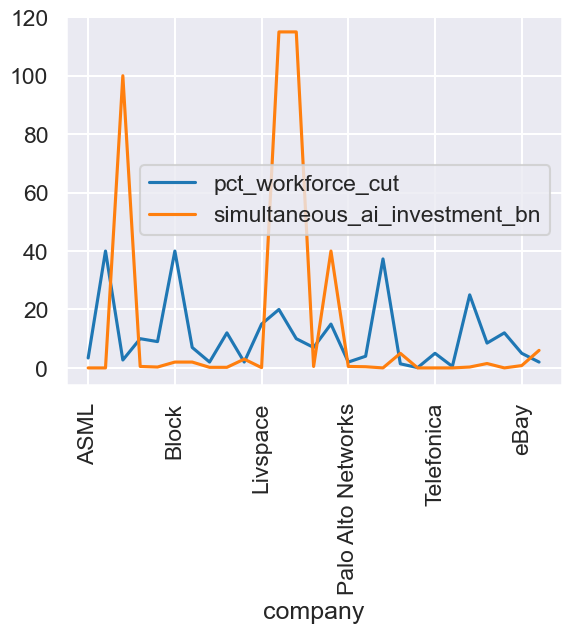

<Figure size 1500x1500 with 0 Axes>

In [187]:
company_df=df_copy.groupby('company')[['pct_workforce_cut','simultaneous_ai_investment_bn']].sum().reset_index()

ax=company_df.plot(x='company',y=['pct_workforce_cut','simultaneous_ai_investment_bn'])
plt.xticks(rotation=90)
plt.figure(figsize=(15,15))


In [ ]:
#ANSWER: It Varies

#### What percentage of laid-off roles have AI replacement roles announced?  


Text(0.5, 1.0, 'laid-off roles replaced by ai')

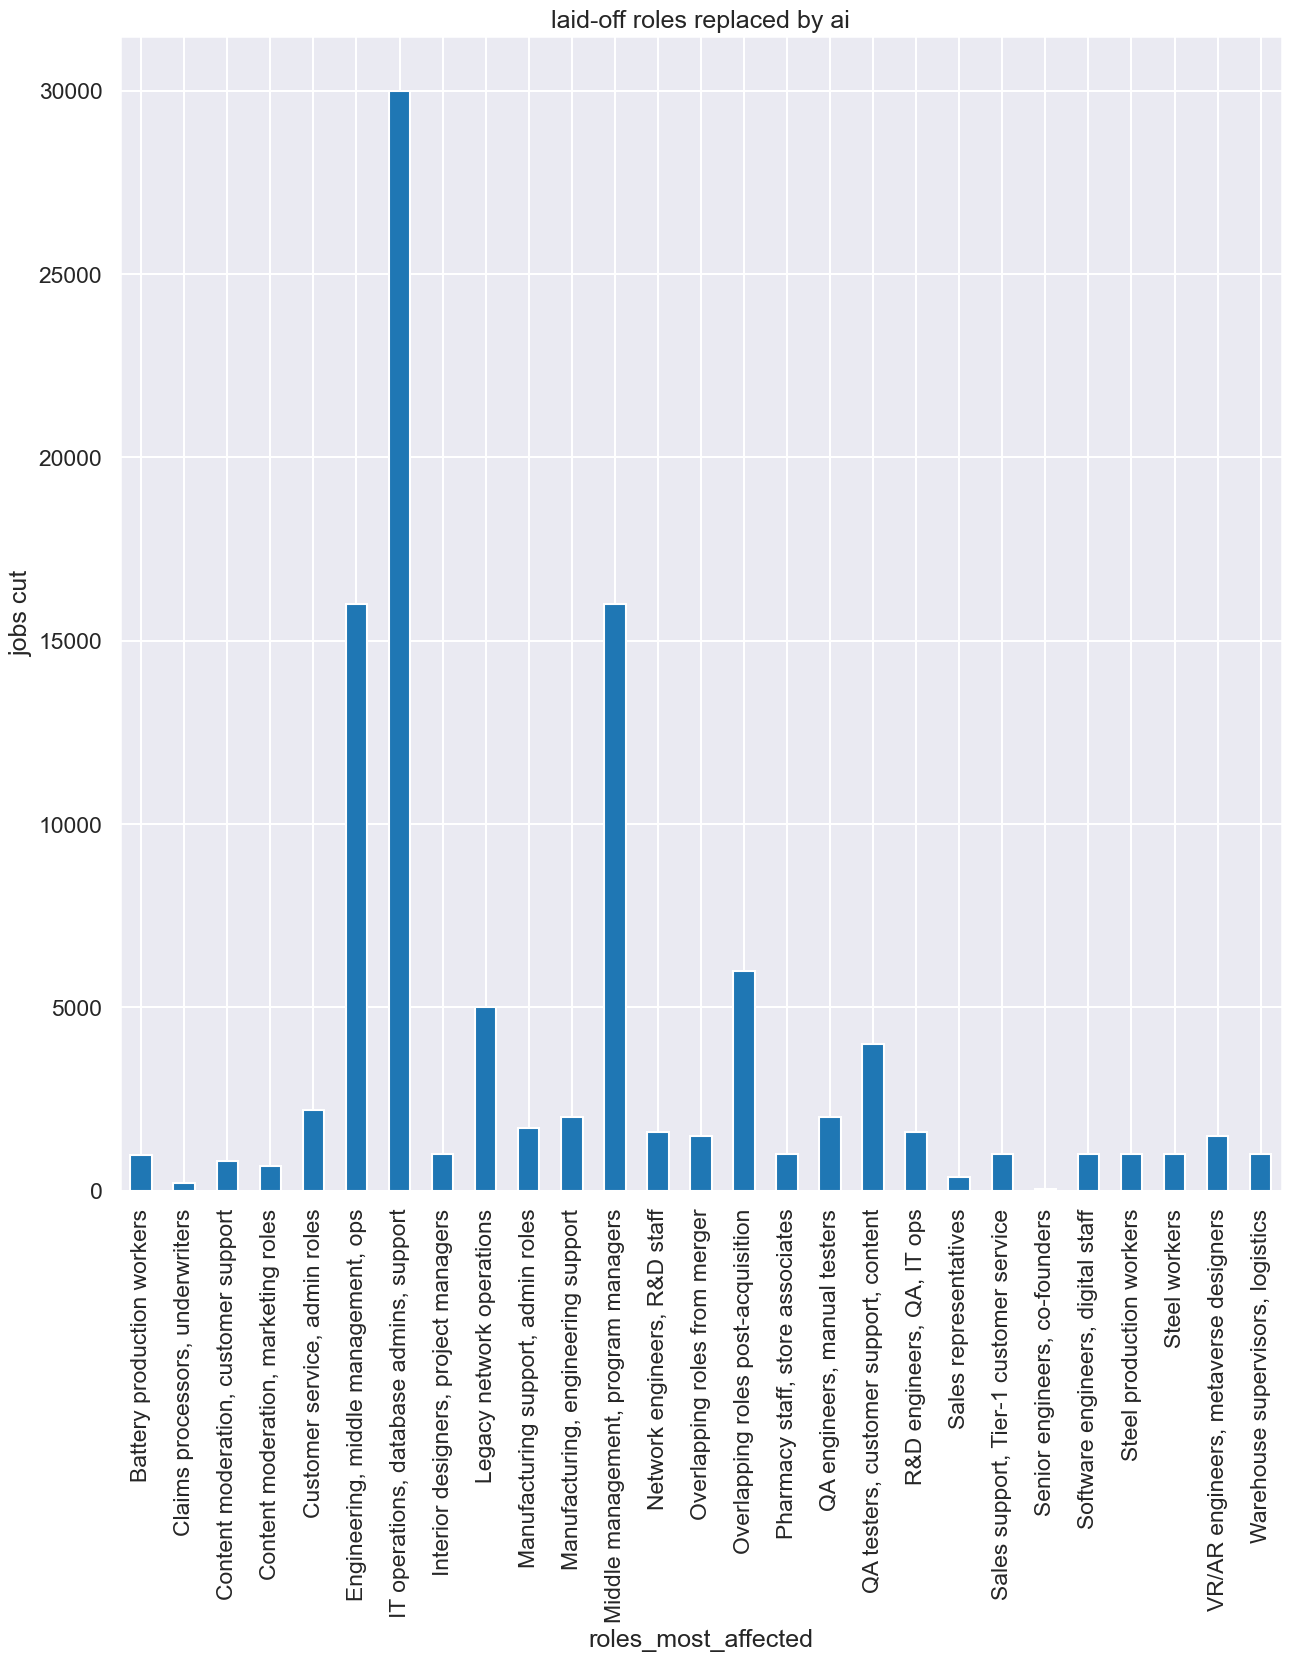

In [193]:
plt.figure(figsize=(15,15))
df_copy.groupby('roles_most_affected')['jobs_cut'].sum().plot(kind='bar')
plt.ylabel('jobs cut')
plt.title('laid-off roles replaced by ai')

#### Are layoffs getting larger or smaller as 2026 progresses?  

<Axes: title={'center': 'Layoff rate from 2024 - 2026'}, xlabel='layoff_count'>

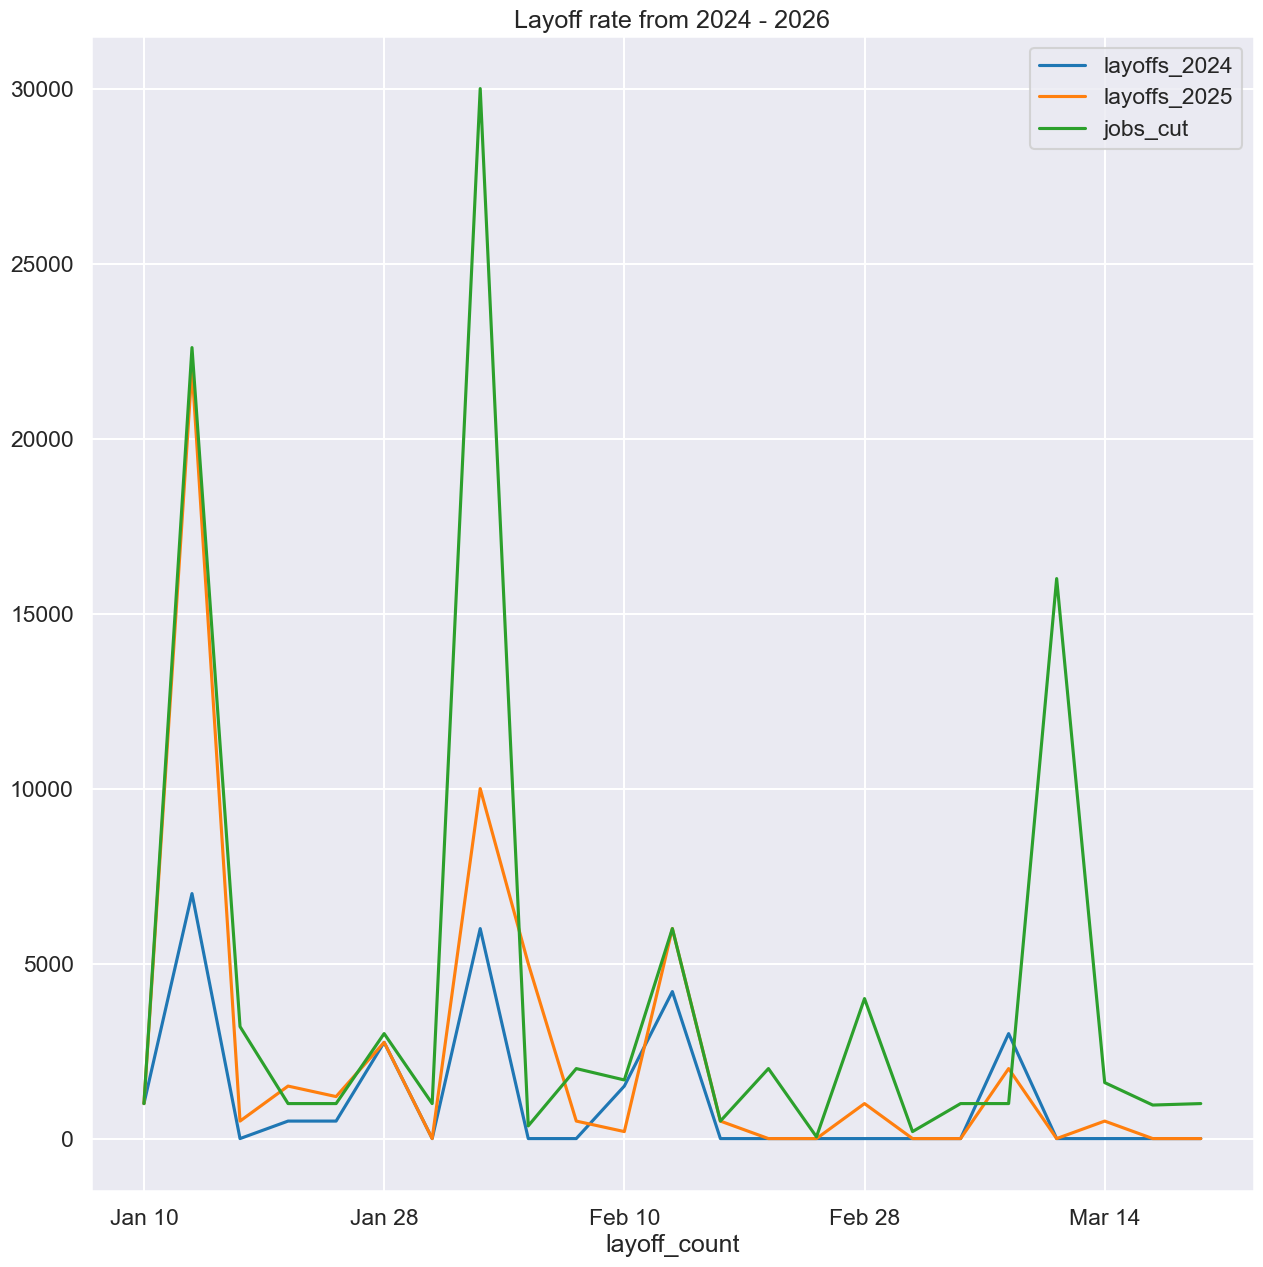

In [209]:
layoff_freq = df_copy.groupby('layoff_date')[['layoffs_2024','layoffs_2025','jobs_cut']].sum().reset_index()
layoff_freq['month_day']=layoff_freq['layoff_date'].dt.strftime('%b %d')



layoff_freq.plot(x='month_day', y=['layoffs_2024','layoffs_2025','jobs_cut'],figsize=(15,15),xlabel='layoff_count',title='Layoff rate from 2024 - 2026')


In [206]:
# Answer: it is increasing rapidly